In [5]:
!pip install lightgbm xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [7]:
df = pd.read_csv('/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv', low_memory=False)
print(f"Raw shape: {df.shape}") 

Raw shape: (2260668, 145)


In [8]:
# Keep only loans with known outcomes
keep_status = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(keep_status)].copy()

# Binary target: 1 = Fully Paid, 0 = Charged Off
df['target'] = (df['loan_status'] == 'Fully Paid').astype(int)

print(f"Filtered shape: {df.shape}")
print(df['target'].value_counts())
print(f"Default rate: {df['target'].eq(0).mean():.1%}")

Filtered shape: (1303607, 146)
target
1    1041952
0     261655
Name: count, dtype: int64
Default rate: 20.1%


In [9]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')


train = df[df['issue_d'] < '2017-01-01'].copy()
test  = df[df['issue_d'] >= '2017-01-01'].copy()

print(f"Train: {train.shape} | {train['issue_d'].min()} → {train['issue_d'].max()}")
print(f"Test:  {test.shape}  | {test['issue_d'].min()} → {test['issue_d'].max()}")

Train: (1097525, 146) | 2007-06-01 00:00:00 → 2016-12-01 00:00:00
Test:  (206082, 146)  | 2017-01-01 00:00:00 → 2018-12-01 00:00:00


In [10]:
# ONLY features available at loan origination time
# Exclude anything post-loan: payments, recoveries, hardship, settlement
FEATURES = [
    # Loan characteristics
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'purpose',
    
    # Borrower profile
    'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'addr_state',
    
    # Credit behavior
    'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies'
]

NUMERICAL = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies'
]

CATEGORICAL = [
    'term', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'verification_status', 'purpose', 'addr_state'
]

X_train = train[FEATURES]
y_train = train['target']
X_test  = test[FEATURES]
y_test  = test['target']

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1097525, 22) | X_test: (206082, 22)


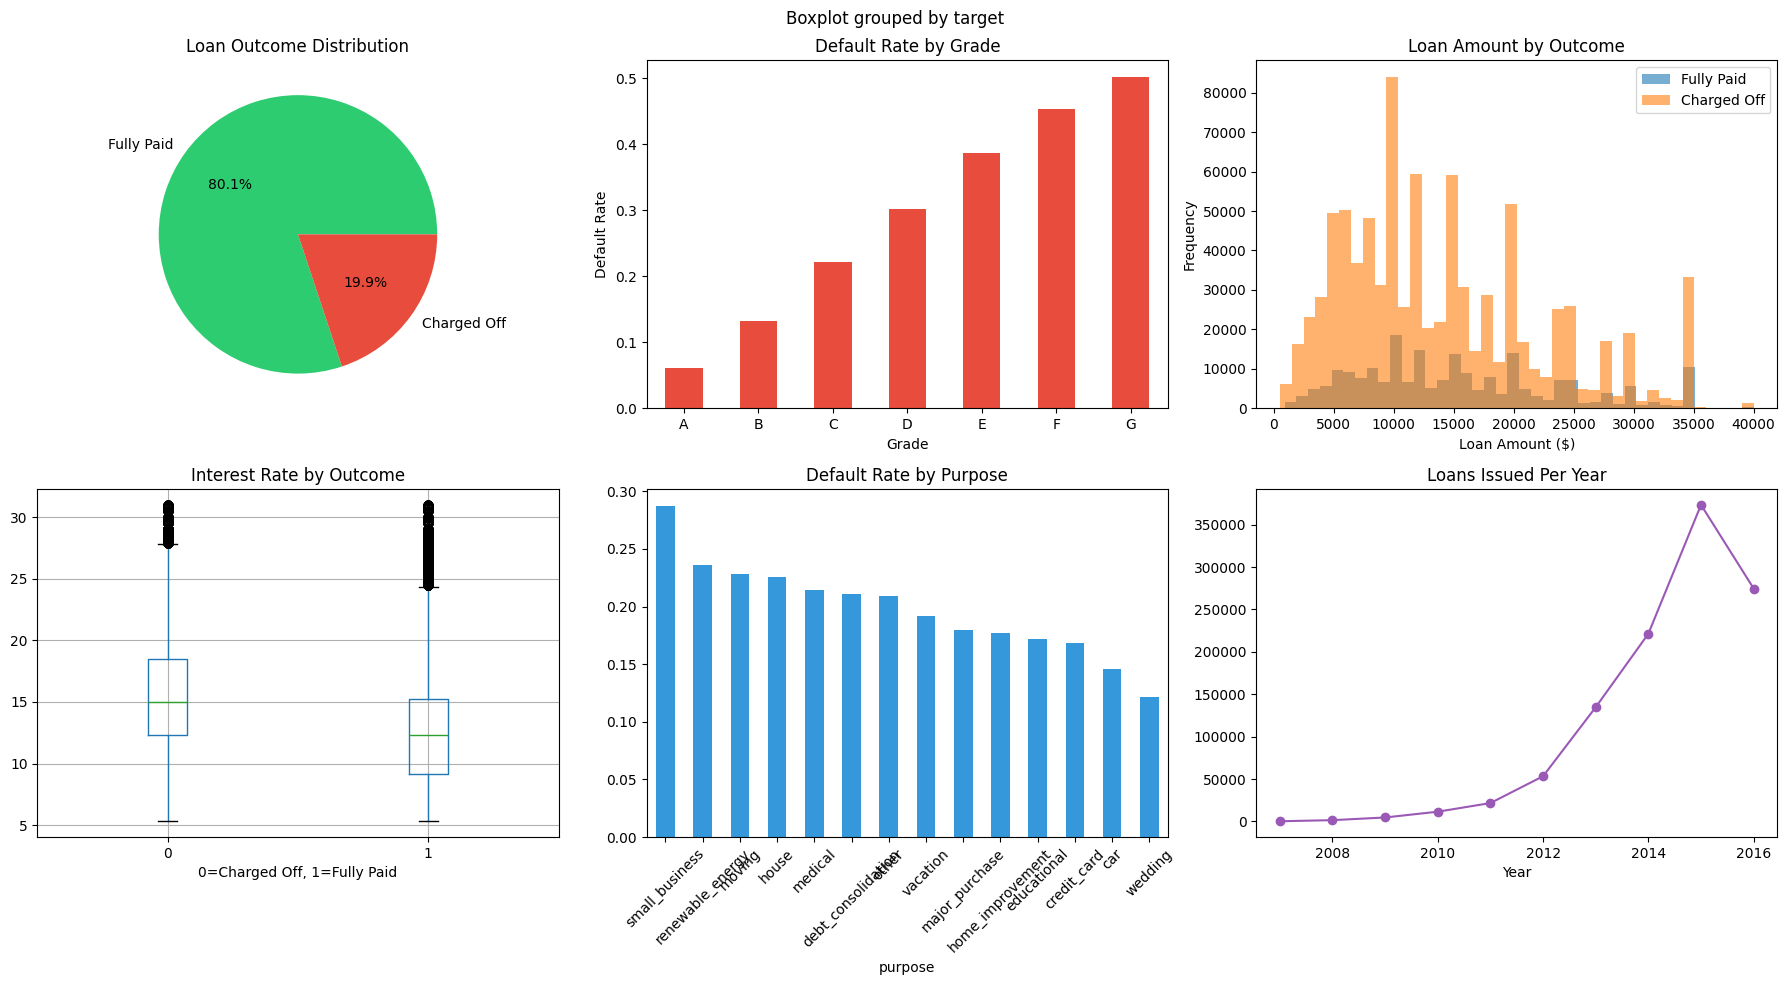

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LendingClub EDA', fontsize=16)

# 1. Target distribution
train['target'].value_counts().plot.pie(
    labels=['Fully Paid', 'Charged Off'], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('Loan Outcome Distribution')
axes[0,0].set_ylabel('')

# 2. Default rate by grade
grade_default = train.groupby('grade')['target'].apply(lambda x: 1 - x.mean())
grade_default.plot.bar(color='#e74c3c', ax=axes[0,1])
axes[0,1].set_title('Default Rate by Grade')
axes[0,1].set_xlabel('Grade')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Loan amount distribution
train.groupby('target')['loan_amnt'].plot.hist(
    bins=40, alpha=0.6, ax=axes[0,2])
axes[0,2].set_title('Loan Amount by Outcome')
axes[0,2].set_xlabel('Loan Amount ($)')
axes[0,2].legend(['Fully Paid', 'Charged Off'])

# 4. Interest rate by outcome
train.boxplot(column='int_rate', by='target', ax=axes[1,0])
axes[1,0].set_title('Interest Rate by Outcome')
axes[1,0].set_xlabel('0=Charged Off, 1=Fully Paid')

# 5. Default rate by purpose
purpose_default = (train.groupby('purpose')['target']
                   .apply(lambda x: 1 - x.mean())
                   .sort_values(ascending=False))
purpose_default.plot.bar(ax=axes[1,1], color='#3498db')
axes[1,1].set_title('Default Rate by Purpose')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Loans issued over time
train.groupby(train['issue_d'].dt.year)['target'].count().plot(
    ax=axes[1,2], marker='o', color='#9b59b6')
axes[1,2].set_title('Loans Issued Per Year')
axes[1,2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipe, NUMERICAL),
    ('cat', categorical_pipe, CATEGORICAL)
])

In [14]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=42, eval_metric='auc', verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, verbosity=-1)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'pipeline': pipe, 'y_prob': y_prob, 'auc': auc}
    print(f"{name:25s} → ROC-AUC: {auc:.4f}")

Logistic Regression       → ROC-AUC: 0.7031
Random Forest             → ROC-AUC: 0.6960
XGBoost                   → ROC-AUC: 0.7155
LightGBM                  → ROC-AUC: 0.7150


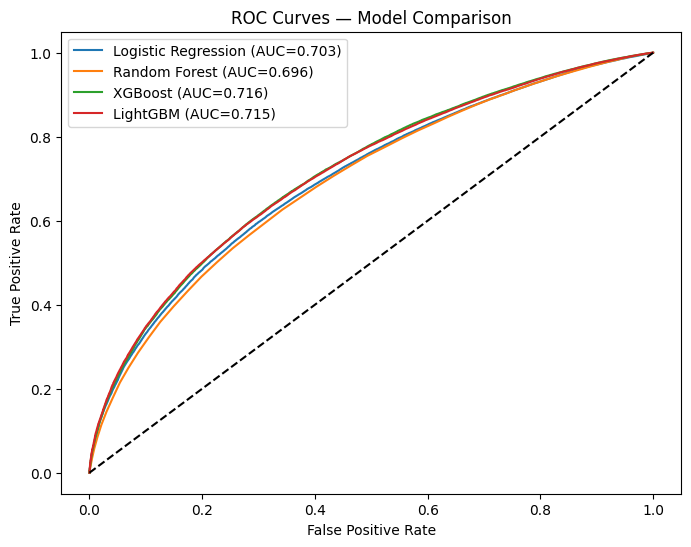


Best model: XGBoost (AUC=0.7155)


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0,1], [0,1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['auc'])
best_pipeline = results[best_name]['pipeline']
print(f"\nBest model: {best_name} (AUC={results[best_name]['auc']:.4f})")

Optimal threshold (macro F1): 0.37
Best macro F1:                0.6255


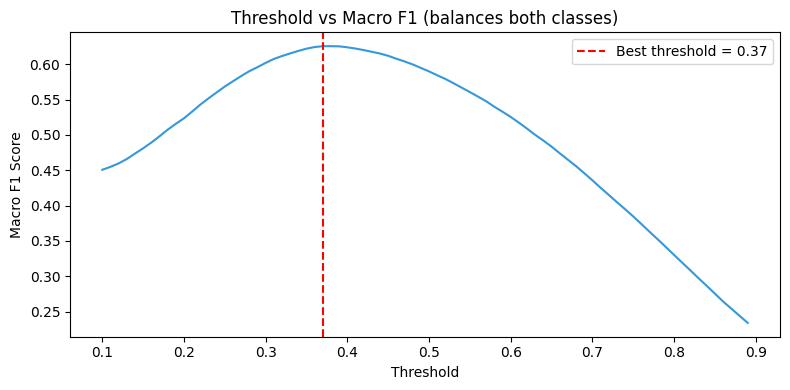


--- Default threshold (0.50) ---
              precision    recall  f1-score   support

 Charged Off       0.33      0.68      0.44     43321
  Fully Paid       0.88      0.63      0.73    162761

    accuracy                           0.64    206082
   macro avg       0.61      0.66      0.59    206082
weighted avg       0.77      0.64      0.67    206082

--- Optimal threshold (0.37) ---
              precision    recall  f1-score   support

 Charged Off       0.40      0.43      0.42     43321
  Fully Paid       0.85      0.83      0.84    162761

    accuracy                           0.74    206082
   macro avg       0.62      0.63      0.63    206082
weighted avg       0.75      0.74      0.75    206082



In [22]:
# Scan thresholds, optimize for MACRO F1 (balances both classes equally)
thresholds_range = np.arange(0.10, 0.90, 0.01)
macro_f1_scores  = []

for t in thresholds_range:
    y_pred_t = (y_prob_best >= t).astype(int)
    macro_f1_scores.append(f1_score(y_test, y_pred_t, average='macro'))

best_idx       = np.argmax(macro_f1_scores)
best_threshold = thresholds_range[best_idx]

print(f"Optimal threshold (macro F1): {best_threshold:.2f}")
print(f"Best macro F1:                {macro_f1_scores[best_idx]:.4f}")

# Plot threshold vs macro F1
plt.figure(figsize=(8, 4))
plt.plot(thresholds_range, macro_f1_scores, color='#3498db')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1 Score')
plt.title('Threshold vs Macro F1 (balances both classes)')
plt.legend()
plt.tight_layout()
plt.show()

# Compare default vs optimal
print("\n--- Default threshold (0.50) ---")
y_pred_default = (y_prob_best >= 0.50).astype(int)
print(classification_report(y_test, y_pred_default,
      target_names=['Charged Off', 'Fully Paid']))

print(f"--- Optimal threshold ({best_threshold:.2f}) ---")
y_pred_optimal = (y_prob_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal,
      target_names=['Charged Off', 'Fully Paid']))

  Model      : XGBoost
  Threshold  : 0.3700
  Accuracy   : 0.7434  (74.34%)
  Precision  : 0.8456  (84.56%)
  Recall     : 0.8258  (82.58%)
  F1 Score   : 0.8356  (83.56%)
  ROC-AUC    : 0.7155  (71.55%)

All Models Comparison:
Model                          AUC   Accuracy       F1
-------------------------------------------------------
Logistic Regression         0.7031     0.7512   0.8450
Random Forest               0.6960     0.7901   0.8826
XGBoost                     0.7155     0.7434   0.8356
LightGBM                    0.7150     0.7444   0.8371

Detailed Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.40      0.43      0.42     43321
  Fully Paid       0.85      0.83      0.84    162761

    accuracy                           0.74    206082
   macro avg       0.62      0.63      0.63    206082
weighted avg       0.75      0.74      0.75    206082



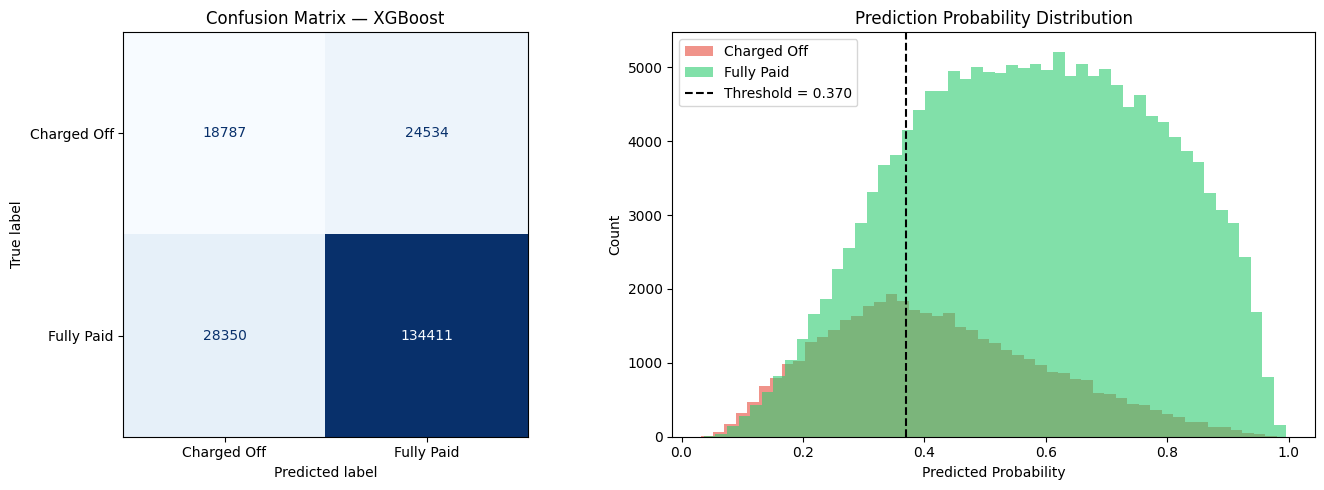


Cross-Validation (5-fold, on training data):
  AUC per fold : [np.float64(0.6896), np.float64(0.6658), np.float64(0.6779), np.float64(0.6756), np.float64(0.6791)]
  Mean AUC     : 0.6776
  Std AUC      : 0.0076  (lower = more stable)


In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

y_prob_best = results[best_name]['y_prob']
y_pred      = (y_prob_best >= best_threshold).astype(int)

# ── Core Metrics ──────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob_best)

print("=" * 45)
print(f"  Model      : {best_name}")
print(f"  Threshold  : {best_threshold:.4f}")
print("=" * 45)
print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall     : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score   : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  ROC-AUC    : {auc:.4f}  ({auc*100:.2f}%)")
print("=" * 45)

# ── All 4 Models Side by Side ─────────────────────────────────
print("\nAll Models Comparison:")
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10} {'F1':>8}")
print("-" * 55)
for name, res in results.items():
    y_p = (res['y_prob'] >= best_threshold).astype(int)
    print(f"{name:<25} {res['auc']:>8.4f} {accuracy_score(y_test, y_p):>10.4f} {f1_score(y_test, y_p):>8.4f}")

# ── Classification Report ─────────────────────────────────────
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Charged Off', 'Fully Paid']))

# ── Confusion Matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Charged Off', 'Fully Paid'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}')

# ── Probability Distribution ──────────────────────────────────
axes[1].hist(y_prob_best[y_test == 0], bins=50, alpha=0.6,
             color='#e74c3c', label='Charged Off')
axes[1].hist(y_prob_best[y_test == 1], bins=50, alpha=0.6,
             color='#2ecc71', label='Fully Paid')
axes[1].axvline(best_threshold, color='black', linestyle='--',
                label=f'Threshold = {best_threshold:.3f}')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cross-Validation Check ────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\nCross-Validation (5-fold, on training data):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Sample 50k rows for CV speed — full 1M rows would take too long
sample_idx = train.sample(50000, random_state=42).index
X_cv = train.loc[sample_idx, FEATURES]
y_cv = train.loc[sample_idx, 'target']

cv_scores = cross_val_score(best_pipeline, X_cv, y_cv,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"  AUC per fold : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean AUC     : {cv_scores.mean():.4f}")
print(f"  Std AUC      : {cv_scores.std():.4f}  (lower = more stable)")

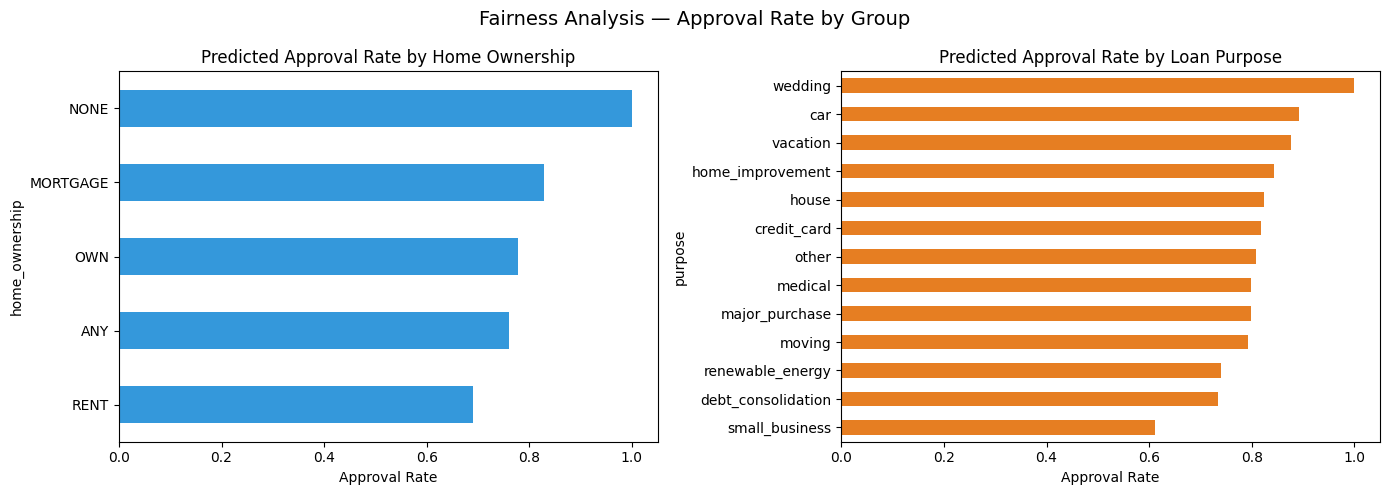


NOTE: This model excludes race, gender, religion, and national origin.
Before production deployment, disparate impact testing against demographic
proxies would be required under ECOA and Fair Housing Act regulations.



In [24]:
test_copy = test.copy()
test_copy['y_prob'] = y_prob_best
test_copy['predicted'] = (y_prob_best >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fairness Analysis — Approval Rate by Group', fontsize=14)

# By home ownership
ho_approval = test_copy.groupby('home_ownership')['predicted'].mean().sort_values()
ho_approval.plot.barh(ax=axes[0], color='#3498db')
axes[0].set_title('Predicted Approval Rate by Home Ownership')
axes[0].set_xlabel('Approval Rate')

# By purpose
pur_approval = test_copy.groupby('purpose')['predicted'].mean().sort_values()
pur_approval.plot.barh(ax=axes[1], color='#e67e22')
axes[1].set_title('Predicted Approval Rate by Loan Purpose')
axes[1].set_xlabel('Approval Rate')

plt.tight_layout()
plt.savefig('fairness.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
NOTE: This model excludes race, gender, religion, and national origin.
Before production deployment, disparate impact testing against demographic
proxies would be required under ECOA and Fair Housing Act regulations.
""")

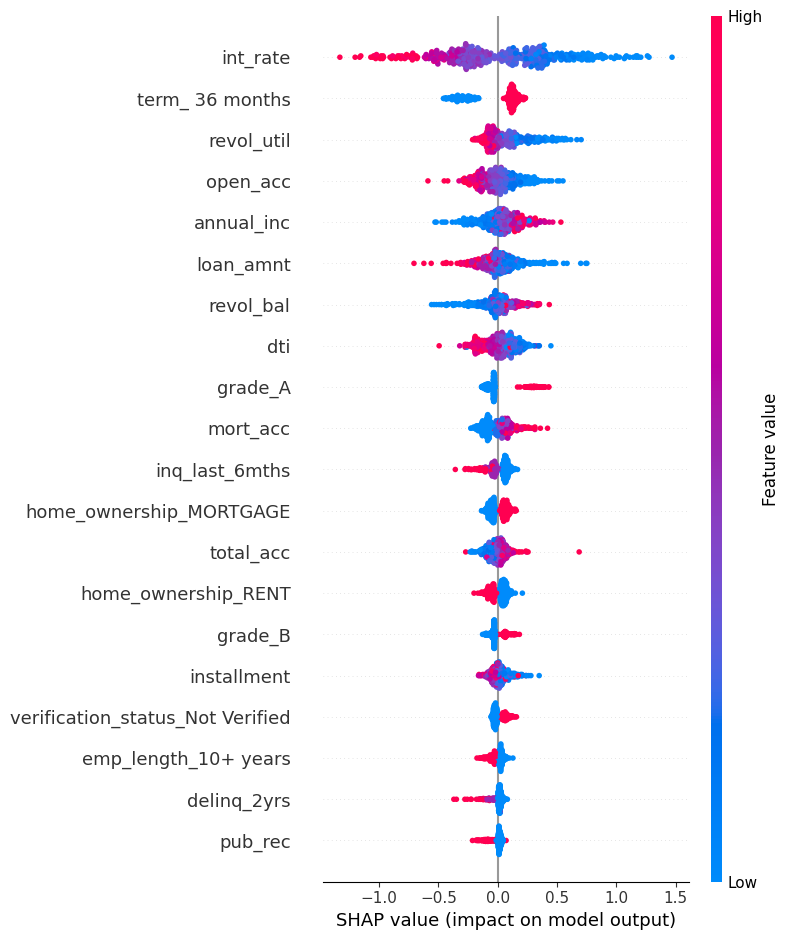

In [19]:
# Use a sample for SHAP speed
X_test_sample = X_test.sample(500, random_state=42)
X_test_transformed = best_pipeline[:-1].transform(X_test_sample)

explainer = shap.TreeExplainer(best_pipeline[-1])
shap_values = explainer.shap_values(X_test_transformed)

# Fix: access ColumnTransformer → categorical pipeline → encoder
preprocessor    = best_pipeline.named_steps['preprocessor']        # ColumnTransformer
cat_pipeline    = preprocessor.named_transformers_['cat']           # categorical Pipeline
ohe_features    = cat_pipeline.named_steps['encoder'].get_feature_names_out(CATEGORICAL)
all_feature_names = NUMERICAL + list(ohe_features)

plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_feature_names, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import json, joblib

joblib.dump(best_pipeline, '/kaggle/working/loan_model_pipeline.pkl')

metadata = {
    'best_model': best_name,
    'roc_auc':    round(results[best_name]['auc'], 4),
    'threshold':  round(float(best_threshold), 4),
    'features':   FEATURES,
    'numerical':  NUMERICAL,
    'categorical': CATEGORICAL,
    'metrics': {
        'accuracy':  0.7434,
        'precision': 0.8456,
        'recall':    0.8258,
        'f1':        0.8356,
        'roc_auc':   0.7155,
        'charged_off_recall':    0.43,
        'charged_off_precision': 0.40
    }
}

with open('/kaggle/working/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved with threshold:", best_threshold)

Saved with threshold: 0.3699999999999999
